In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler


# ============================================================
# LOAD DATASET
# ============================================================

file_path = r"/content/earthquake_data.csv"

df = pd.read_csv(file_path)

print("Original Dataset:")
print(df.head())

print("\nDataset Information:")
df.info()




Original Dataset:
                                          title  magnitude         date_time  \
0  M 7.0 - 18 km SW of Malango, Solomon Islands        7.0  22-11-2022 02:03   
1      M 6.9 - 204 km SW of Bengkulu, Indonesia        6.9  18-11-2022 13:37   
2                                      M 7.0 -         7.0  12-11-2022 07:09   
3           M 7.3 - 205 km ESE of Neiafu, Tonga        7.3  11-11-2022 10:48   
4                                      M 6.6 -         6.6  09-11-2022 10:14   

   cdi  mmi  alert  tsunami  sig net  nst   dmin   gap magType    depth  \
0    8    7  green        1  768  us  117  0.509  17.0     mww   14.000   
1    4    4  green        0  735  us   99  2.229  34.0     mww   25.000   
2    3    3  green        1  755  us  147  3.125  18.0     mww  579.000   
3    5    5  green        1  833  us  149  1.865  21.0     mww   37.000   
4    0    2  green        1  670  us  131  4.998  27.0     mww  624.464   

   latitude  longitude                  location c

In [5]:
# ============================================================
# 1. IDENTIFY MISSING VALUES
# ============================================================

print("\nMissing Values in Dataset:")
print(df.isnull())


Missing Values in Dataset:
     title  magnitude  date_time    cdi    mmi  alert  tsunami    sig    net  \
0    False      False      False  False  False  False    False  False  False   
1    False      False      False  False  False  False    False  False  False   
2    False      False      False  False  False  False    False  False  False   
3    False      False      False  False  False  False    False  False  False   
4    False      False      False  False  False  False    False  False  False   
..     ...        ...        ...    ...    ...    ...      ...    ...    ...   
777  False      False      False  False  False   True    False  False  False   
778  False      False      False  False  False   True    False  False  False   
779  False      False      False  False  False   True    False  False  False   
780  False      False      False  False  False   True    False  False  False   
781  False      False      False  False  False   True    False  False  False   

       nst 

In [6]:
# ============================================================
# 2. COUNT MISSING VALUES
# ============================================================

print("\nTotal Missing Values in Each Column:")
print(df.isnull().sum())



Total Missing Values in Each Column:
title          0
magnitude      0
date_time      0
cdi            0
mmi            0
alert        367
tsunami        0
sig            0
net            0
nst            0
dmin           0
gap            0
magType        0
depth          0
latitude       0
longitude      0
location       5
continent    576
country      298
dtype: int64


In [7]:
# ============================================================
# 3. REPLACE MISSING VALUES
# ============================================================

# Numerical columns - replace missing values with mean
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].mean())


# Categorical columns - replace missing values with mode
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    if not df[col].mode().empty:
        df[col] = df[col].fillna(df[col].mode()[0])


print("\nMissing Values After Replacement:")
print(df.isnull().sum())



Missing Values After Replacement:
title        0
magnitude    0
date_time    0
cdi          0
mmi          0
alert        0
tsunami      0
sig          0
net          0
nst          0
dmin         0
gap          0
magType      0
depth        0
latitude     0
longitude    0
location     0
continent    0
country      0
dtype: int64


In [8]:
# ============================================================
# 4. DETECT DUPLICATE RECORDS
# ============================================================

print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())


# Remove duplicate records
df = df.drop_duplicates()


print("\nDuplicate Rows After Removing:")
print(df.duplicated().sum())


Number of Duplicate Rows:
0

Duplicate Rows After Removing:
0


In [9]:
# ============================================================
# 5. DETECT OUTLIERS USING IQR METHOD
# ============================================================

print("\nOutlier Detection:")

# Re-create numeric columns after cleaning
numeric_columns = df.select_dtypes(include=np.number).columns

outlier_result = {}

for col in numeric_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    outlier_result[col] = len(outliers)


print(outlier_result)



Outlier Detection:
{'magnitude': 37, 'cdi': 0, 'mmi': 1, 'tsunami': 0, 'sig': 73, 'nst': 0, 'dmin': 61, 'gap': 48, 'depth': 139, 'latitude': 0, 'longitude': 0}


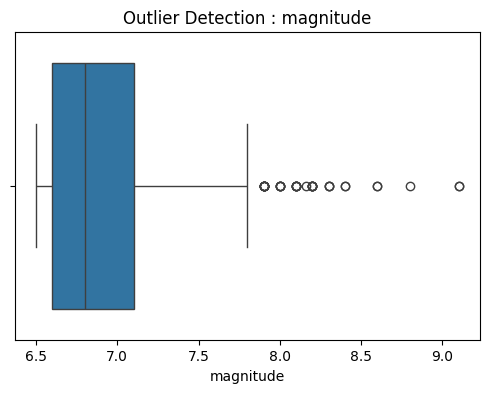

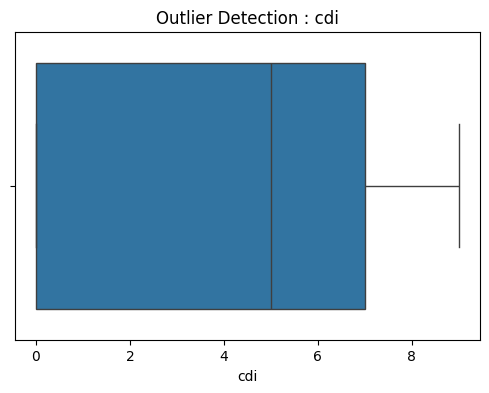

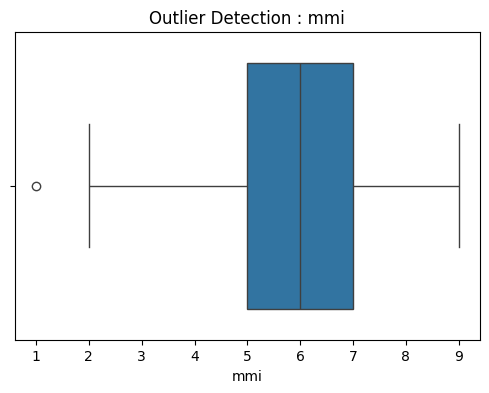

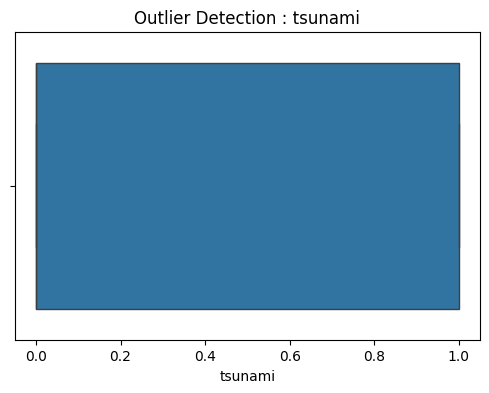

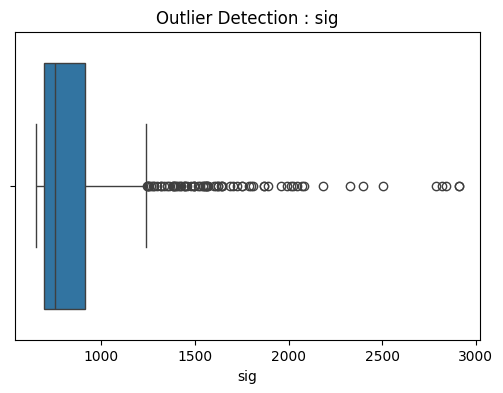

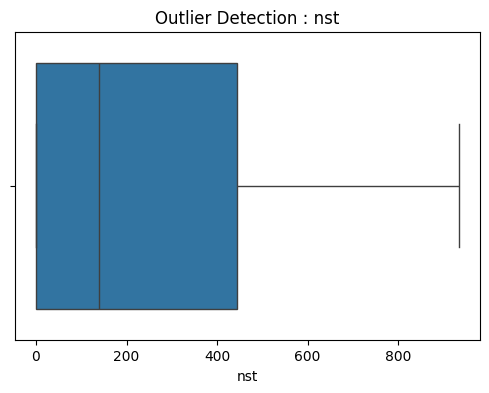

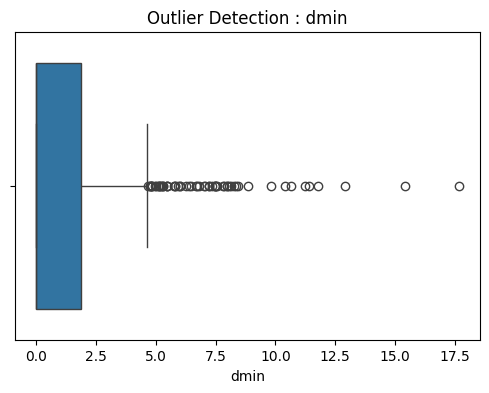

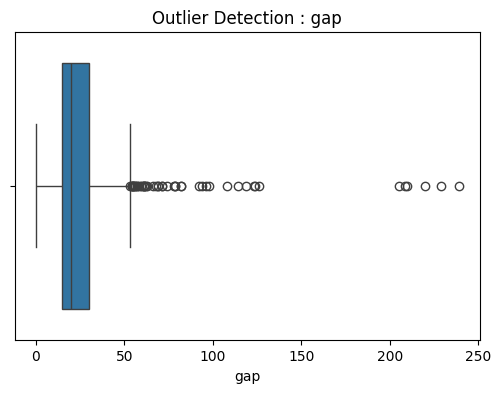

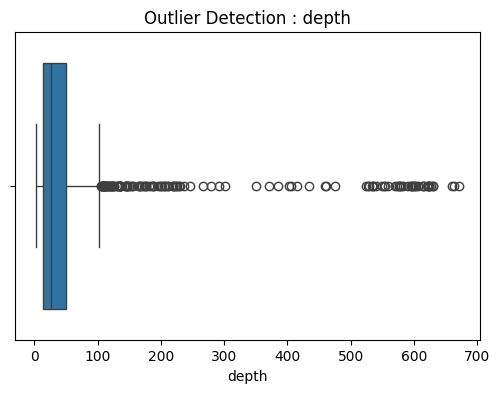

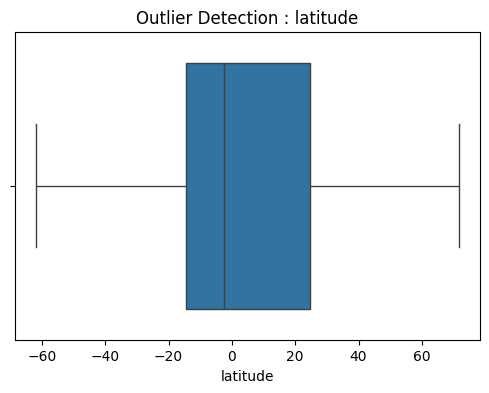

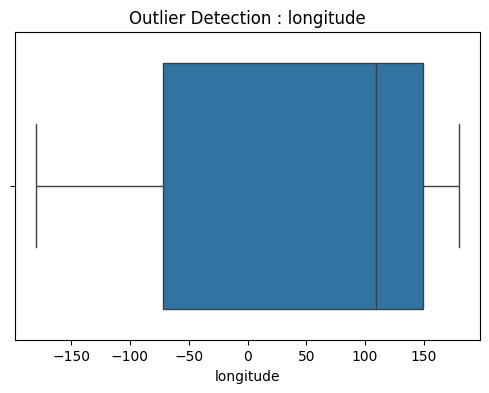

In [10]:
# ============================================================
# 6. OUTLIER VISUALIZATION
# ============================================================

for col in numeric_columns:

    plt.figure(figsize=(6, 4))

    sns.boxplot(x=df[col])

    plt.title("Outlier Detection : " + col)
    plt.xlabel(col)

    plt.show()


In [11]:
# ============================================================
# 7. DATA CLEANING
# ============================================================

# Remove spaces from column names
df.columns = df.columns.str.strip()

# Convert column names into lowercase
df.columns = df.columns.str.lower()

print("\nCleaned Column Names:")
print(df.columns)


Cleaned Column Names:
Index(['title', 'magnitude', 'date_time', 'cdi', 'mmi', 'alert', 'tsunami',
       'sig', 'net', 'nst', 'dmin', 'gap', 'magtype', 'depth', 'latitude',
       'longitude', 'location', 'continent', 'country'],
      dtype='object')


In [12]:
# ============================================================
# 8. DATA TRANSFORMATION
# ============================================================

# IMPORTANT:
# Re-create numeric_columns because the column names
# were changed to lowercase in the previous step.

numeric_columns = df.select_dtypes(include=np.number).columns

# Normalization using MinMaxScaler
scaler = MinMaxScaler()

df[numeric_columns] = scaler.fit_transform(
    df[numeric_columns]
)


print("\nTransformed Dataset:")
print(df.head())



Transformed Dataset:
                                          title  magnitude         date_time  \
0  M 7.0 - 18 km SW of Malango, Solomon Islands   0.192308  22-11-2022 02:03   
1      M 6.9 - 204 km SW of Bengkulu, Indonesia   0.153846  18-11-2022 13:37   
2                                      M 7.0 -    0.192308  12-11-2022 07:09   
3           M 7.3 - 205 km ESE of Neiafu, Tonga   0.307692  11-11-2022 10:48   
4                                      M 6.6 -    0.038462  09-11-2022 10:14   

        cdi    mmi  alert  tsunami       sig net       nst      dmin  \
0  0.888889  0.750  green      1.0  0.052212  us  0.125268  0.028832   
1  0.444444  0.375  green      0.0  0.037611  us  0.105996  0.126260   
2  0.333333  0.250  green      1.0  0.046460  us  0.157388  0.177014   
3  0.555556  0.500  green      1.0  0.080973  us  0.159529  0.105642   
4  0.000000  0.125  green      1.0  0.008850  us  0.140257  0.283109   

        gap magtype     depth  latitude  longitude              

In [14]:
# ============================================================
# 9. SAVE CLEANED DATASET
# ============================================================

output_file = r"/content/earthquake_data.csv"

df.to_csv(
    output_file,
    index=False
)

print("\nCleaned Dataset Saved Successfully!")
print("File Name:", output_file)


Cleaned Dataset Saved Successfully!
File Name: /content/earthquake_data.csv


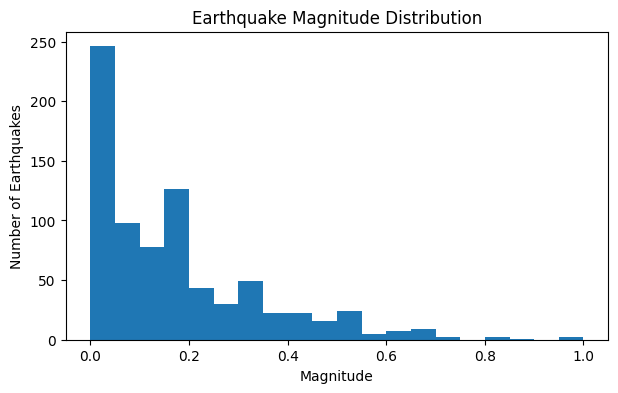

In [15]:
# ============================================================
# 10. EARTHQUAKE-SPECIFIC VISUALIZATIONS
# ============================================================

# ------------------------------------------------------------
# Magnitude Distribution
# ------------------------------------------------------------

plt.figure(figsize=(7, 4))

plt.hist(df["magnitude"], bins=20)

plt.title("Earthquake Magnitude Distribution")
plt.xlabel("Magnitude")
plt.ylabel("Number of Earthquakes")

plt.show()

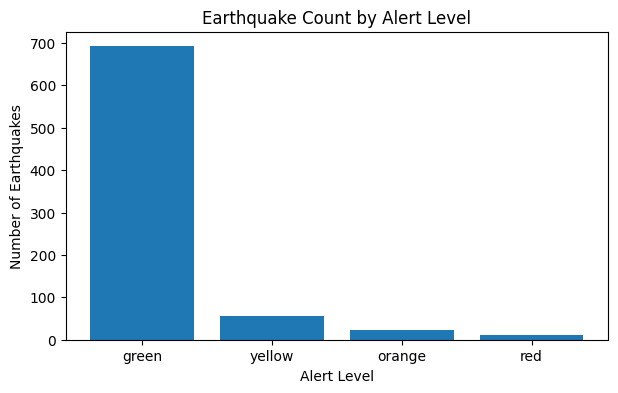

In [16]:
# ------------------------------------------------------------
# Alert Level Distribution
# ------------------------------------------------------------

alert_counts = df["alert"].value_counts()

plt.figure(figsize=(7, 4))

plt.bar(alert_counts.index.astype(str), alert_counts.values)

plt.title("Earthquake Count by Alert Level")
plt.xlabel("Alert Level")
plt.ylabel("Number of Earthquakes")

plt.show()



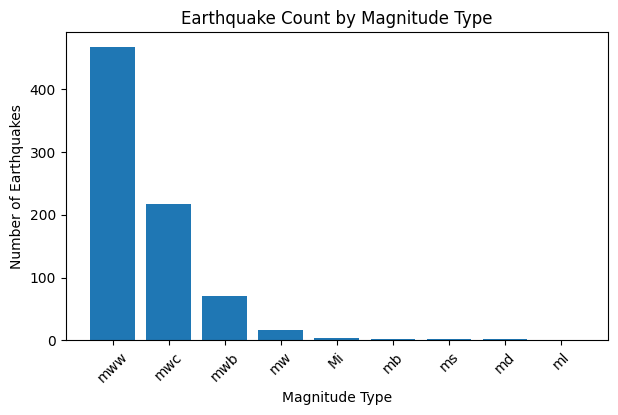

In [17]:
# ------------------------------------------------------------
# Magnitude Type Distribution
# ------------------------------------------------------------

magtype_counts = df["magtype"].value_counts()

plt.figure(figsize=(7, 4))

plt.bar(
    magtype_counts.index.astype(str),
    magtype_counts.values
)

plt.title("Earthquake Count by Magnitude Type")
plt.xlabel("Magnitude Type")
plt.ylabel("Number of Earthquakes")

plt.xticks(rotation=45)

plt.show()


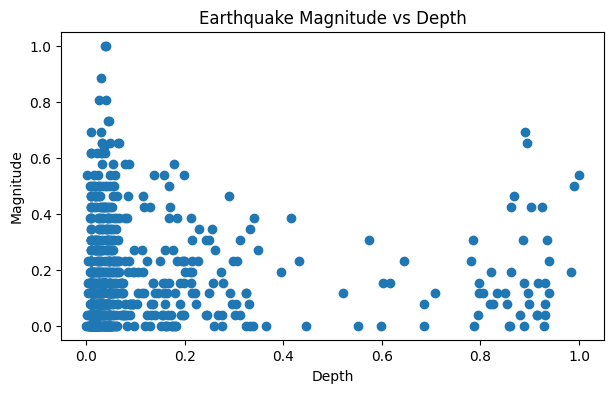

In [18]:
# ------------------------------------------------------------
# Magnitude vs Depth
# ------------------------------------------------------------

plt.figure(figsize=(7, 4))

plt.scatter(
    df["depth"],
    df["magnitude"]
)

plt.title("Earthquake Magnitude vs Depth")
plt.xlabel("Depth")
plt.ylabel("Magnitude")

plt.show()

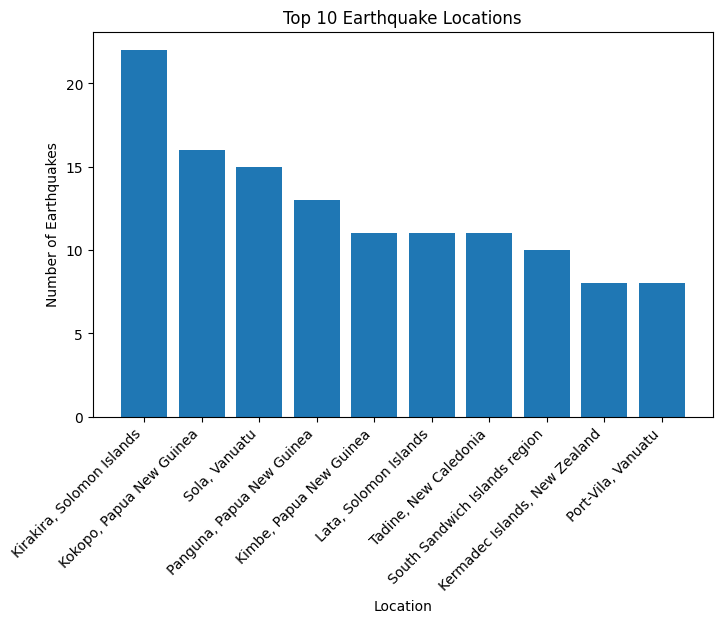

In [19]:
# ------------------------------------------------------------
# Earthquake Locations
# ------------------------------------------------------------

top_locations = df["location"].value_counts().head(10)

plt.figure(figsize=(8, 5))

plt.bar(
    top_locations.index.astype(str),
    top_locations.values
)

plt.title("Top 10 Earthquake Locations")
plt.xlabel("Location")
plt.ylabel("Number of Earthquakes")

plt.xticks(rotation=45, ha="right")

plt.show()